# Лабораторная работа №2
## «Виртуальный датчик для контроля процесса обжига в печи»

**Цель:** построить виртуальный датчик, который прогнозирует концентрацию выходного продукта по минутной телеметрии печи с учетом временной динамики процесса и задержки лабораторных измерений.

**Идея решения:** лабораторные замеры приходят нерегулярно и с задержкой 10–15 минут, поэтому целевой показатель синхронизируется с телеметрией по оценочному моменту отбора пробы: `sample_datetime = lab_datetime - 15 минут`. После этого строятся лаговые и скользящие признаки, обучаются несколько регрессионных моделей, качество сравнивается на отдельном test-периоде.

In [1]:
from pathlib import Path
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
RANDOM_STATE = 42

## 1. Загрузка данных

Ноутбук можно запускать как из корня репозитория, где есть папка `data/`, так и из директории, где CSV-файлы лежат рядом с ноутбуком.

In [2]:
DATA_DIR = Path("data") if Path("data/data_train.csv").exists() else Path(".")

telemetry_train = pd.read_csv(DATA_DIR / "data_train.csv", parse_dates=["datetime"])
target_train = pd.read_csv(DATA_DIR / "target_train.csv", parse_dates=["Дата"]).rename(columns={"Дата": "lab_datetime"})
telemetry_test = pd.read_csv(DATA_DIR / "data_test_small.csv", parse_dates=["datetime"])
target_test = pd.read_csv(DATA_DIR / "target_test_small.csv", parse_dates=["Дата"]).rename(columns={"Дата": "lab_datetime"})

print("Размеры таблиц:")
print("telemetry_train:", telemetry_train.shape)
print("target_train:   ", target_train.shape)
print("telemetry_test: ", telemetry_test.shape)
print("target_test:    ", target_test.shape)

print("\nПериоды данных:")
for name, df, col in [
    ("telemetry_train", telemetry_train, "datetime"),
    ("target_train", target_train, "lab_datetime"),
    ("telemetry_test", telemetry_test, "datetime"),
    ("target_test", target_test, "lab_datetime"),
]:
    print(f"{name:16s}: {df[col].min()} — {df[col].max()}")

display(telemetry_train.head())
display(target_train.head())

Размеры таблиц:
telemetry_train: (319546, 17)
target_train:    (1773, 2)
telemetry_test:  (39943, 17)
target_test:     (318, 2)

Периоды данных:
telemetry_train : 2019-03-01 00:01:00 — 2019-10-07 19:58:00
target_train    : 2019-03-13 17:00:00 — 2019-10-07 21:00:00
telemetry_test  : 2019-10-07 19:59:00 — 2019-11-04 10:25:00
target_test     : 2019-10-07 23:00:00 — 2019-11-04 09:00:00


,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15
0,2019-03-01 00:01:00,0.737538,0.478367,0.292816,0.644016,0.919471,0.884814,0.754800,0.413295,0.47192,0.677801,0.687535,0.498407,NaN,NaN,NaN,NaN
1,2019-03-01 00:02:00,0.738406,0.478977,0.292816,0.648557,0.919471,0.887129,0.752977,0.413295,0.47192,0.677801,0.688926,0.498407,NaN,NaN,NaN,NaN
2,2019-03-01 00:03:00,0.738985,0.478977,0.292816,0.647164,0.919471,0.887129,0.755444,0.413295,0.47192,0.677801,0.690316,0.498407,NaN,NaN,NaN,NaN
3,2019-03-01 00:04:00,0.739563,0.478977,0.292816,0.636938,0.919471,0.887129,0.754800,0.413295,0.47192,0.678079,0.692820,0.498407,NaN,NaN,NaN,NaN
4,2019-03-01 00:05:00,0.740431,0.477119,0.292816,0.635834,0.919471,0.887707,0.754156,0.413295,0.47192,0.678357,0.695601,0.498407,NaN,NaN,NaN,NaN


,lab_datetime,target
0,2019-03-13 17:00:00,0.123711
1,2019-03-13 21:00:00,0.319588
2,2019-03-14 01:00:00,0.255155
3,2019-03-14 05:00:00,0.319588
4,2019-03-14 09:00:00,0.159794


## 2. EDA: телеметрия, пропуски, выбросы, лабораторные замеры

Доля пропусков по датчикам, %:


,missing_%
telemetry_12,99.343444
telemetry_13,99.343444
telemetry_14,99.343444
telemetry_15,99.343444
telemetry_4,0.041622
telemetry_0,0.005320
telemetry_5,0.005320
telemetry_1,0.005007
telemetry_2,0.005007
telemetry_3,0.005007


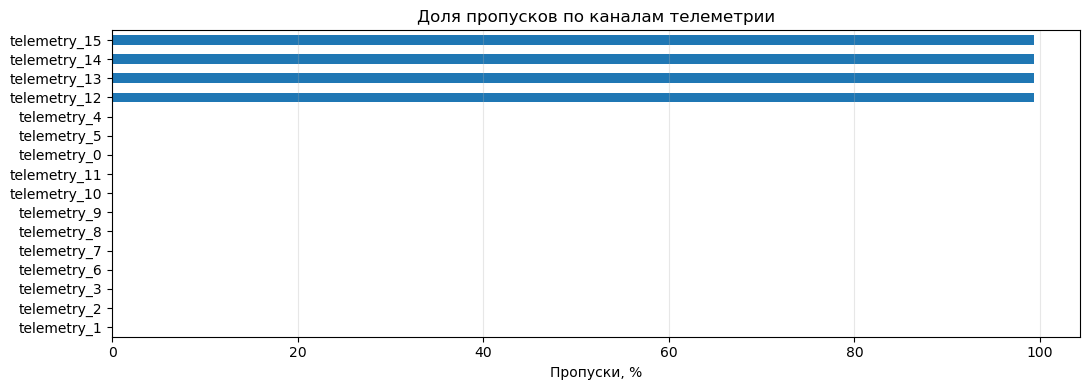

In [3]:
telemetry_cols = [c for c in telemetry_train.columns if c.startswith("telemetry_")]

missing_summary = telemetry_train[telemetry_cols].isna().mean().mul(100).sort_values(ascending=False).rename("missing_%").to_frame()
print("Доля пропусков по датчикам, %:")
display(missing_summary)

fig, ax = plt.subplots(figsize=(11, 4))
missing_summary.sort_values("missing_%").plot(kind="barh", ax=ax, legend=False)
ax.set_title("Доля пропусков по каналам телеметрии")
ax.set_xlabel("Пропуски, %")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

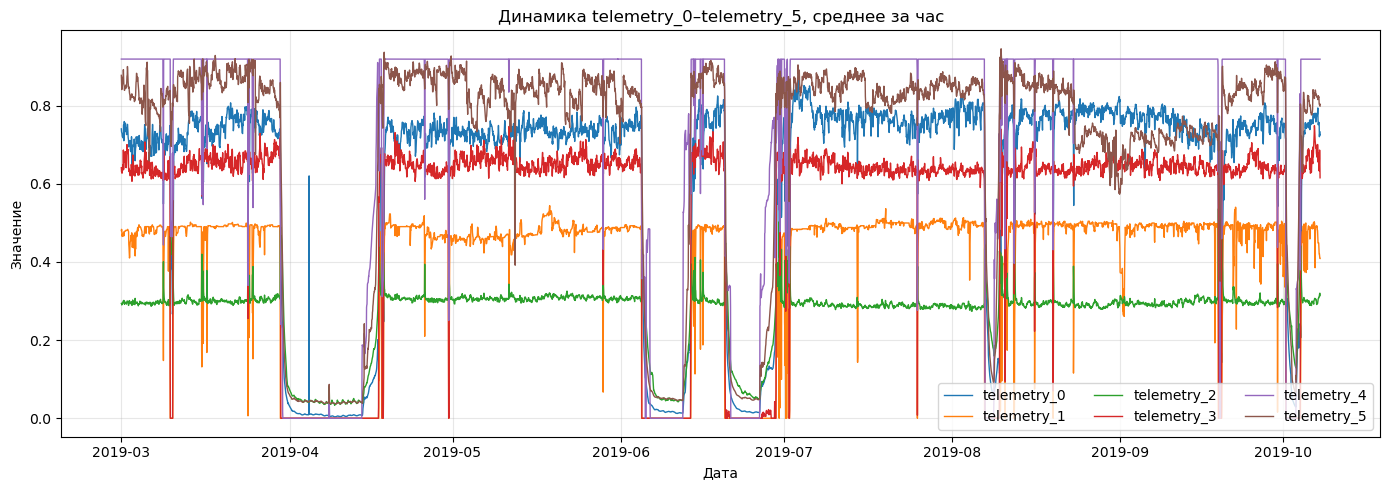

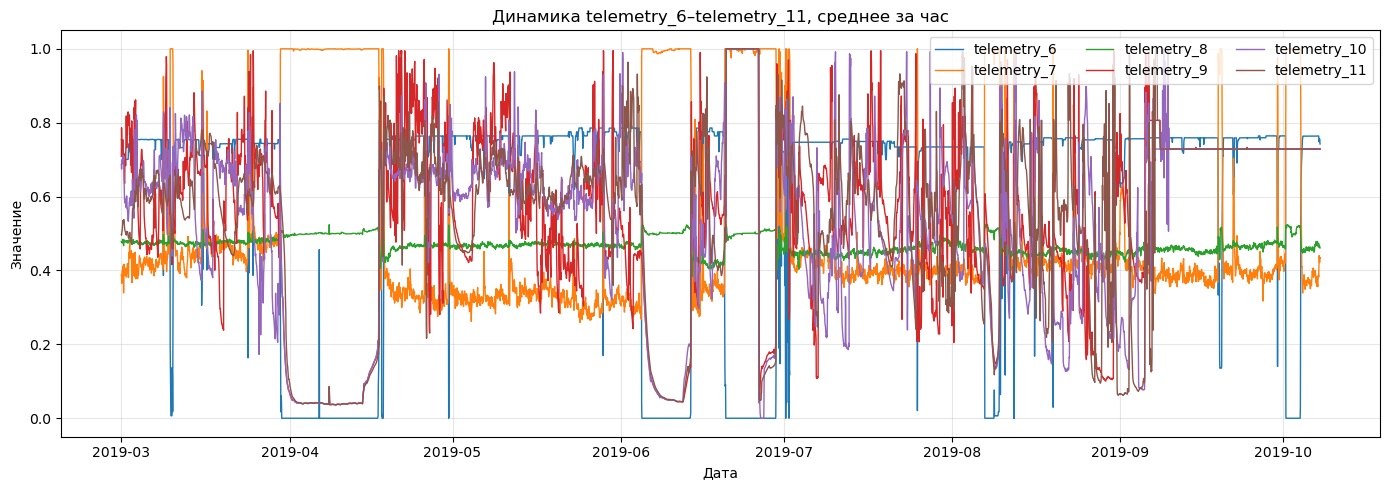

In [4]:
# Для читаемости графиков минутную телеметрию агрегируем до среднечасовой.
hourly_train = telemetry_train.set_index("datetime")[telemetry_cols].resample("1H").mean()

fig, ax = plt.subplots(figsize=(14, 5))
for col in telemetry_cols[:6]:
    ax.plot(hourly_train.index, hourly_train[col], label=col, linewidth=1)
ax.set_title("Динамика telemetry_0–telemetry_5, среднее за час")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend(ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
for col in telemetry_cols[6:12]:
    ax.plot(hourly_train.index, hourly_train[col], label=col, linewidth=1)
ax.set_title("Динамика telemetry_6–telemetry_11, среднее за час")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend(ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Описание телеметрии:


,count,mean,std,min,25%,50%,75%,max
telemetry_0,319529.0,0.609997,0.276324,0.003472,0.687771,0.738985,0.768498,1.000000
telemetry_1,319530.0,0.379998,0.197845,0.000000,0.431430,0.486093,0.494401,0.610826
telemetry_2,319530.0,0.266786,0.088145,0.031828,0.285872,0.295710,0.304679,1.000000
telemetry_3,319530.0,0.520080,0.259314,0.000000,0.617462,0.639479,0.658350,1.000000
telemetry_4,319413.0,0.762045,0.325663,0.000000,0.919214,0.919471,0.919471,1.000000
telemetry_5,319529.0,0.695864,0.284229,0.000000,0.716705,0.829549,0.863402,1.000000
telemetry_6,319530.0,0.594029,0.300451,0.000000,0.700847,0.749222,0.759198,1.000000
telemetry_7,319530.0,0.522708,0.252911,0.020644,0.366226,0.410817,0.492155,1.000000
telemetry_8,319530.0,0.469582,0.023767,0.344030,0.454270,0.467869,0.482336,1.000000
telemetry_9,319530.0,0.535833,0.254748,0.000000,0.391050,0.581846,0.728682,1.000000


Описание target_train:


,count,mean,std,min,25%,50%,75%,max
target,1773.0,0.254272,0.092208,0.0,0.175258,0.247423,0.314433,0.716495


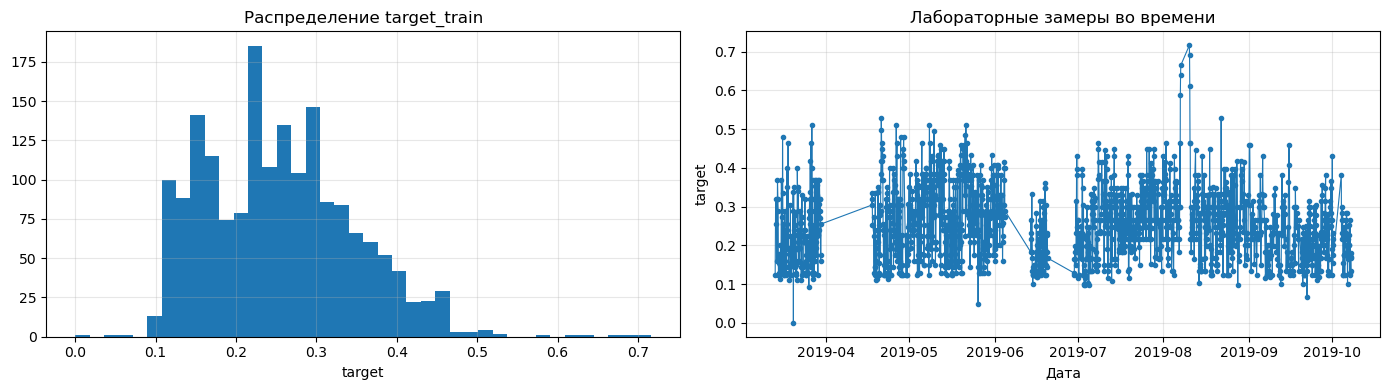

In [5]:
print("Описание телеметрии:")
display(telemetry_train[telemetry_cols].describe().T)

print("Описание target_train:")
display(target_train["target"].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(target_train["target"], bins=40)
axes[0].set_title("Распределение target_train")
axes[0].set_xlabel("target")
axes[0].grid(True, alpha=0.3)

axes[1].plot(target_train["lab_datetime"], target_train["target"], marker=".", linewidth=0.8)
axes[1].set_title("Лабораторные замеры во времени")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("target")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


train: частые интервалы между лабораторными замерами


,count
lab_datetime,
0 days 02:00:00,1570
0 days 04:00:00,184
0 days 01:00:00,4
0 days 07:00:00,2
0 days 01:30:00,1
18 days 08:30:00,1
0 days 11:00:00,1
0 days 14:00:00,1
9 days 06:00:00,1



test: частые интервалы между лабораторными замерами


,count
lab_datetime,
0 days 02:00:00,315
0 days 10:00:00,1
0 days 18:00:00,1


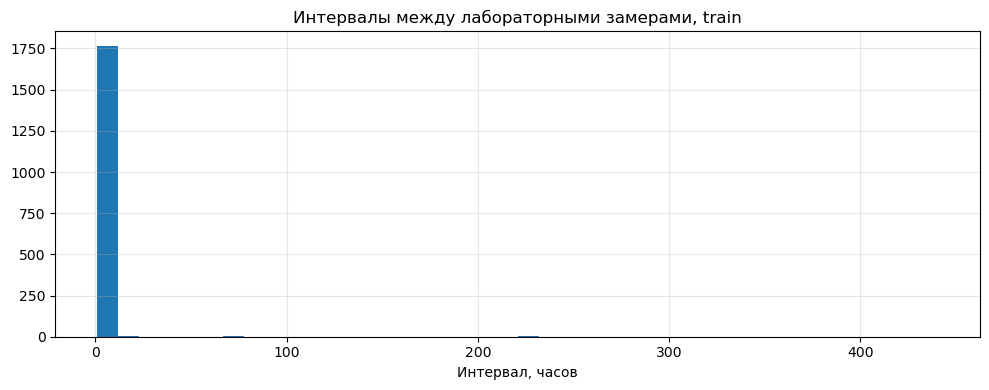

In [6]:
# Анализ частоты лабораторных измерений
for name, df in [("train", target_train), ("test", target_test)]:
    intervals = df["lab_datetime"].sort_values().diff().dropna()
    print(f"\n{name}: частые интервалы между лабораторными замерами")
    display(intervals.value_counts().head(10).to_frame("count"))

interval_hours = target_train["lab_datetime"].sort_values().diff().dropna().dt.total_seconds() / 3600
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(interval_hours, bins=40)
ax.set_title("Интервалы между лабораторными замерами, train")
ax.set_xlabel("Интервал, часов")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Оценка выбросов по IQR. В промышленном процессе выбросы не удаляем автоматически,
# потому что они могут соответствовать реальным переходным или аварийным режимам.
outlier_rows = []
for col in telemetry_cols:
    s = telemetry_train[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_rows.append({
        "feature": col,
        "lower_iqr": lower,
        "upper_iqr": upper,
        "outlier_%": ((s < lower) | (s > upper)).mean() * 100,
    })
outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_%", ascending=False)
display(outlier_summary)

,feature,lower_iqr,upper_iqr,outlier_%
1,telemetry_1,0.336974,0.588857,22.570964
6,telemetry_6,0.613322,0.846723,22.080869
7,telemetry_7,0.177333,0.681049,22.009201
4,telemetry_4,0.918828,0.919857,21.393306
0,telemetry_0,0.566680,0.889588,21.299788
2,telemetry_2,0.257661,0.332890,21.276249
3,telemetry_3,0.556131,0.719682,20.609958
5,telemetry_5,0.496659,1.083448,17.995550
14,telemetry_14,0.215909,0.670455,1.286940
8,telemetry_8,0.412170,0.524436,1.254968


### Вывод по EDA

- Основные каналы `telemetry_0`–`telemetry_11` почти полностью заполнены и пригодны для построения признаков.
- `telemetry_12`–`telemetry_15` имеют критически высокую долю пропусков, поэтому в базовой модели исключаются.
- Лабораторные замеры существенно реже минутной телеметрии и в основном идут с шагом около 2 часов, поэтому нужен отдельный этап синхронизации.
- Выбросы не удаляются механически: для печи они могут отражать реальные нестабильные режимы процесса.

## 3. Синхронизация лабораторных замеров и телеметрии

Для каждого лабораторного результата используется момент отбора пробы `lab_datetime - 15 минут`. Затем через `merge_asof(..., direction="backward")` берется ближайшая телеметрия, доступная на тот момент или раньше. Это защищает решение от утечки будущей информации.

In [8]:
missing_ratio = telemetry_train[telemetry_cols].isna().mean()
usable_telemetry_cols = [c for c in telemetry_cols if missing_ratio[c] < 0.30]
dropped_telemetry_cols = [c for c in telemetry_cols if c not in usable_telemetry_cols]

print("Используемые каналы:", usable_telemetry_cols)
print("Исключенные каналы:", dropped_telemetry_cols)


def prepare_telemetry_features(df, use_cols, lags=(15, 60, 120), windows=(15, 60)):
    """Создает только прошлые признаки: лаги, rolling mean/std, разности."""
    df = df.sort_values("datetime").copy()
    df[use_cols] = df[use_cols].astype("float32")
    df[use_cols] = df[use_cols].interpolate(limit=10, limit_direction="both").ffill().bfill()

    chunks = [df[["datetime"] + use_cols].copy()]

    for lag in lags:
        shifted = df[use_cols].shift(lag).astype("float32")
        shifted.columns = [f"{c}_lag_{lag}m" for c in use_cols]
        chunks.append(shifted)

    for window in windows:
        roll = df[use_cols].rolling(window=window, min_periods=max(3, window // 3))
        mean = roll.mean().astype("float32")
        mean.columns = [f"{c}_roll_mean_{window}m" for c in use_cols]
        std = roll.std().astype("float32")
        std.columns = [f"{c}_roll_std_{window}m" for c in use_cols]
        chunks.extend([mean, std])

    for delta in (15, 60):
        diff = df[use_cols].diff(delta).astype("float32")
        diff.columns = [f"{c}_diff_{delta}m" for c in use_cols]
        chunks.append(diff)

    return pd.concat(chunks, axis=1)


def align_target_with_features(target_df, feature_df, delay_minutes=15):
    target_df = target_df.copy().sort_values("lab_datetime")
    target_df["sample_datetime"] = target_df["lab_datetime"] - pd.to_timedelta(delay_minutes, unit="m")

    aligned = pd.merge_asof(
        target_df.sort_values("sample_datetime"),
        feature_df.sort_values("datetime"),
        left_on="sample_datetime",
        right_on="datetime",
        direction="backward",
        tolerance=pd.Timedelta("2min"),
    )
    aligned = aligned.rename(columns={"datetime": "telemetry_datetime"})
    aligned["sync_gap_min"] = (aligned["sample_datetime"] - aligned["telemetry_datetime"]).dt.total_seconds() / 60
    return aligned.dropna(subset=["target"]).sort_values("lab_datetime")

Используемые каналы: ['telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7', 'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11']
Исключенные каналы: ['telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']


In [9]:
t0 = time.time()
features_train = prepare_telemetry_features(telemetry_train, usable_telemetry_cols)
features_test = prepare_telemetry_features(telemetry_test, usable_telemetry_cols)
train_aligned = align_target_with_features(target_train, features_train, delay_minutes=15)
test_aligned = align_target_with_features(target_test, features_test, delay_minutes=15)
print(f"Feature engineering + sync time: {time.time() - t0:.2f} sec")
print("train_aligned:", train_aligned.shape)
print("test_aligned: ", test_aligned.shape)
display(train_aligned[["lab_datetime", "sample_datetime", "telemetry_datetime", "sync_gap_min", "target"]].head())
display(train_aligned["sync_gap_min"].describe().to_frame().T)

Feature engineering + sync time: 1.06 sec
train_aligned: (1773, 125)
test_aligned:  (318, 125)


,lab_datetime,sample_datetime,telemetry_datetime,sync_gap_min,target
0,2019-03-13 17:00:00,2019-03-13 16:45:00,2019-03-13 16:45:00,0.0,0.123711
1,2019-03-13 21:00:00,2019-03-13 20:45:00,2019-03-13 20:45:00,0.0,0.319588
2,2019-03-14 01:00:00,2019-03-14 00:45:00,2019-03-14 00:45:00,0.0,0.255155
3,2019-03-14 05:00:00,2019-03-14 04:45:00,2019-03-14 04:45:00,0.0,0.319588
4,2019-03-14 09:00:00,2019-03-14 08:45:00,2019-03-14 08:45:00,0.0,0.159794


,count,mean,std,min,25%,50%,75%,max
sync_gap_min,1772.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Вывод по синхронизации

Синхронизация построена так, чтобы модель имитировала реальный виртуальный датчик: на момент прогноза ей доступны только текущие и прошлые значения телеметрии. Это особенно важно для промышленной задачи, где оператор должен получить оценку target до фактического получения лабораторного результата.

## 4. Инжиниринг признаков и лаговый анализ

Созданы признаки, отражающие временную динамику:

- текущие значения датчиков;
- лаги на 15, 60 и 120 минут;
- скользящие средние и стандартные отклонения за 15 и 60 минут;
- изменения показателей за 15 и 60 минут.

Количество признаков: 120
Top-20 признаков по абсолютной корреляции с target:


,corr_with_target
telemetry_3_lag_15m,-0.178859
telemetry_0,-0.177327
telemetry_0_roll_mean_15m,-0.176525
telemetry_0_lag_15m,-0.170852
telemetry_0_roll_mean_60m,-0.165052
telemetry_3_roll_mean_60m,-0.162898
telemetry_3_roll_mean_15m,-0.142181
telemetry_0_lag_60m,-0.133798
telemetry_3,-0.127028
telemetry_3_lag_60m,-0.121892


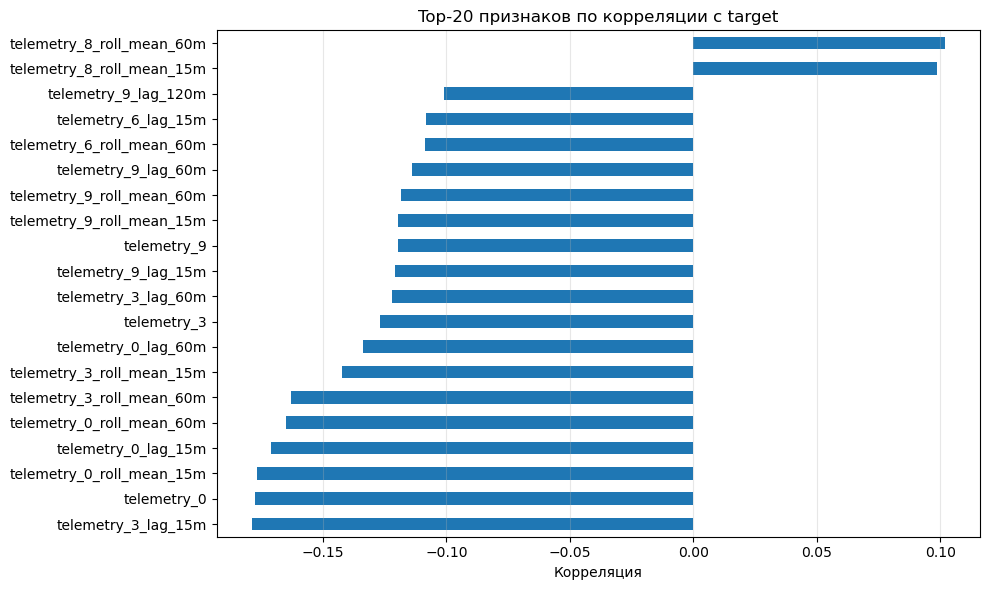

X_train: (1773, 120)
X_test:  (318, 120)


In [10]:
feature_cols = [c for c in train_aligned.columns if c.startswith("telemetry_") and c != "telemetry_datetime"]

corr = (
    train_aligned[feature_cols + ["target"]]
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print(f"Количество признаков: {len(feature_cols)}")
print("Top-20 признаков по абсолютной корреляции с target:")
display(corr.head(20).to_frame("corr_with_target"))

fig, ax = plt.subplots(figsize=(10, 6))
corr.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top-20 признаков по корреляции с target")
ax.set_xlabel("Корреляция")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

X_train = train_aligned[feature_cols].astype("float32")
y_train = train_aligned["target"].astype("float32")
X_test = test_aligned[feature_cols].astype("float32")
y_test = test_aligned["target"].astype("float32")

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

### Вывод по признакам

Лаги и rolling-признаки имеют понятную технологическую интерпретацию: печь обладает инерцией, поэтому качество продукта зависит не только от текущего состояния, но и от предыдущего режима. Такой набор признаков лучше подходит для виртуального датчика, чем использование только текущих значений датчиков.

## 5. Построение моделей

Обучаются 4 модели:

1. `Ridge` — интерпретируемый линейный baseline;
2. `RandomForestRegressor` — нелинейная ансамблевая модель;
3. `GradientBoostingRegressor` — бустинг над деревьями для табличных лаговых признаков;
4. `SARIMAX + PCA(exog)` — статистическая модель временного ряда с внешними регрессорами и AIC/BIC.

**Что не подходит как основной вариант:** обычная ARIMA без телеметрии, случайное train/test-разбиение, KNN, классификация и глубокие LSTM-модели как стартовое MVP. Причины: игнорирование внешних датчиков, утечка по времени, слабая интерпретируемость или слишком мало лабораторных target-точек для устойчивого обучения сложной нейросети.

In [11]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.abs(y_true) > 1e-8
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100)


def directional_accuracy(y_true, y_pred):
    dy_true = np.diff(np.asarray(y_true))
    dy_pred = np.diff(np.asarray(y_pred))
    mask = dy_true != 0
    return float(np.mean(np.sign(dy_true[mask]) == np.sign(dy_pred[mask]))) if mask.any() else np.nan


def gaussian_aic_bic(y_true, y_pred, k):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    sigma2 = max(rss / n, 1e-12)
    return float(n * np.log(sigma2) + 2 * k), float(n * np.log(sigma2) + k * np.log(n))

In [12]:
models = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0)),
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=30,
            max_depth=10,
            min_samples_leaf=8,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
    "GradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            n_estimators=70,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=8,
            random_state=RANDOM_STATE,
        )),
    ]),
}

predictions = {}
fitted_models = {}
metrics_rows = []

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    elapsed = time.time() - t0
    predictions[name] = pred
    fitted_models[name] = model

    row = {
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAPE_%": mape(y_test, pred),
        "WAPE_%": wape(y_test, pred),
        "DirectionalAccuracy": directional_accuracy(y_test, pred),
        "fit_predict_sec": elapsed,
        "AIC": np.nan,
        "BIC": np.nan,
    }
    if name == "Ridge":
        row["AIC"], row["BIC"] = gaussian_aic_bic(y_test, pred, k=len(feature_cols) + 1)
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df.sort_values("RMSE"))

,model,MAE,RMSE,MAPE_%,WAPE_%,DirectionalAccuracy,fit_predict_sec,AIC,BIC
2,GradientBoosting,0.061199,0.076227,33.625583,29.183724,0.551495,4.692068,NaN,NaN
1,RandomForest,0.061939,0.077048,33.992994,29.536574,0.501661,0.467085,NaN,NaN
0,Ridge,0.064342,0.082573,36.838391,30.682224,0.528239,0.044493,-1344.232182,-889.023965


In [13]:
# SARIMAX с 3 PCA-компонентами внешних признаков: быстрее и устойчивее,
# чем подавать в SARIMAX сотни коррелированных лагов.
t0 = time.time()

imp = SimpleImputer(strategy="median")
scaler = StandardScaler()
pca = PCA(n_components=3, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(scaler.fit_transform(imp.fit_transform(X_train)))
X_test_pca = pca.transform(scaler.transform(imp.transform(X_test)))

sarimax_model = sm.tsa.SARIMAX(
    y_train.values,
    exog=X_train_pca,
    order=(1, 0, 1),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_result = sarimax_model.fit(disp=False, maxiter=30)
sarimax_pred = np.asarray(sarimax_result.forecast(steps=len(y_test), exog=X_test_pca))
predictions["SARIMAX_PCA"] = sarimax_pred

metrics_df = pd.concat([
    metrics_df,
    pd.DataFrame([{
        "model": "SARIMAX_PCA",
        "MAE": mean_absolute_error(y_test, sarimax_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, sarimax_pred)),
        "MAPE_%": mape(y_test, sarimax_pred),
        "WAPE_%": wape(y_test, sarimax_pred),
        "DirectionalAccuracy": directional_accuracy(y_test, sarimax_pred),
        "fit_predict_sec": time.time() - t0,
        "AIC": sarimax_result.aic,
        "BIC": sarimax_result.bic,
    }])
], ignore_index=True).sort_values("RMSE").reset_index(drop=True)

display(metrics_df)
print("SARIMAX fitted. AIC=", round(sarimax_result.aic, 3), "BIC=", round(sarimax_result.bic, 3))

c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,MAE,RMSE,MAPE_%,WAPE_%,DirectionalAccuracy,fit_predict_sec,AIC,BIC
0,GradientBoosting,0.061199,0.076227,33.625583,29.183724,0.551495,4.692068,NaN,NaN
1,RandomForest,0.061939,0.077048,33.992994,29.536574,0.501661,0.467085,NaN,NaN
2,Ridge,0.064342,0.082573,36.838391,30.682224,0.528239,0.044493,-1344.232182,-889.023965
3,SARIMAX_PCA,0.076440,0.088585,45.609550,36.451571,0.561462,0.920246,-4064.447866,-4026.092768


SARIMAX fitted. AIC= -4064.448 BIC= -4026.093


## 6. Оценка качества и сравнение моделей

Метрики: MAE, RMSE, MAPE, WAPE, Directional Accuracy. Для статистической SARIMAX-модели дополнительно используются AIC/BIC; для Ridge приведена грубая гауссовская оценка AIC/BIC, а для деревьев эти критерии напрямую не интерпретируются.

In [14]:
best_model_name = metrics_df.iloc[0]["model"]
best_pred = predictions[best_model_name]
print("Лучшая модель по RMSE:", best_model_name)
display(metrics_df)

prediction_table = test_aligned[["lab_datetime", "sample_datetime", "target"]].copy()
for name, pred in predictions.items():
    prediction_table[f"pred_{name}"] = pred
prediction_table["best_prediction"] = best_pred
prediction_table["best_residual"] = prediction_table["target"] - prediction_table["best_prediction"]
display(prediction_table.head())

Лучшая модель по RMSE: GradientBoosting


,model,MAE,RMSE,MAPE_%,WAPE_%,DirectionalAccuracy,fit_predict_sec,AIC,BIC
0,GradientBoosting,0.061199,0.076227,33.625583,29.183724,0.551495,4.692068,NaN,NaN
1,RandomForest,0.061939,0.077048,33.992994,29.536574,0.501661,0.467085,NaN,NaN
2,Ridge,0.064342,0.082573,36.838391,30.682224,0.528239,0.044493,-1344.232182,-889.023965
3,SARIMAX_PCA,0.076440,0.088585,45.609550,36.451571,0.561462,0.920246,-4064.447866,-4026.092768


,lab_datetime,sample_datetime,target,pred_Ridge,pred_RandomForest,pred_GradientBoosting,pred_SARIMAX_PCA,best_prediction,best_residual
0,2019-10-07 23:00:00,2019-10-07 22:45:00,0.182990,0.227399,0.176377,0.217527,0.186165,0.217527,-0.034538
1,2019-10-08 01:00:00,2019-10-08 00:45:00,0.164948,0.202488,0.198752,0.196952,0.207166,0.196952,-0.032004
2,2019-10-08 03:00:00,2019-10-08 02:45:00,0.216495,0.200260,0.177217,0.186121,0.221136,0.186121,0.030374
3,2019-10-08 05:00:00,2019-10-08 04:45:00,0.134021,0.212504,0.206580,0.200765,0.229930,0.200765,-0.066744
4,2019-10-08 07:00:00,2019-10-08 06:45:00,0.231959,0.182991,0.198860,0.191066,0.236177,0.191066,0.040893


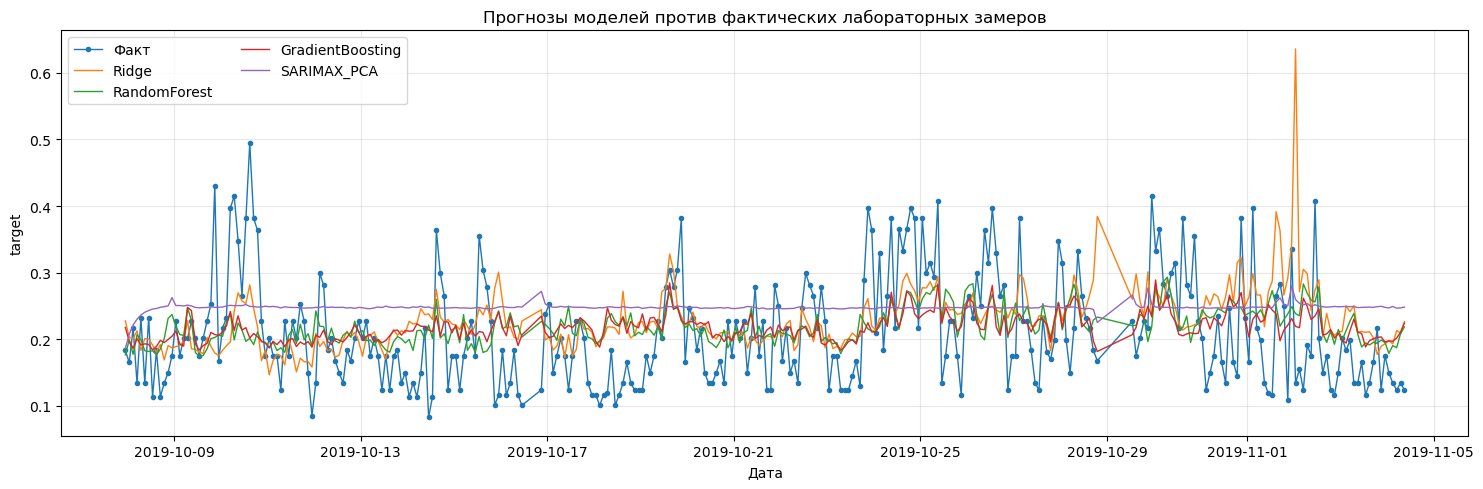

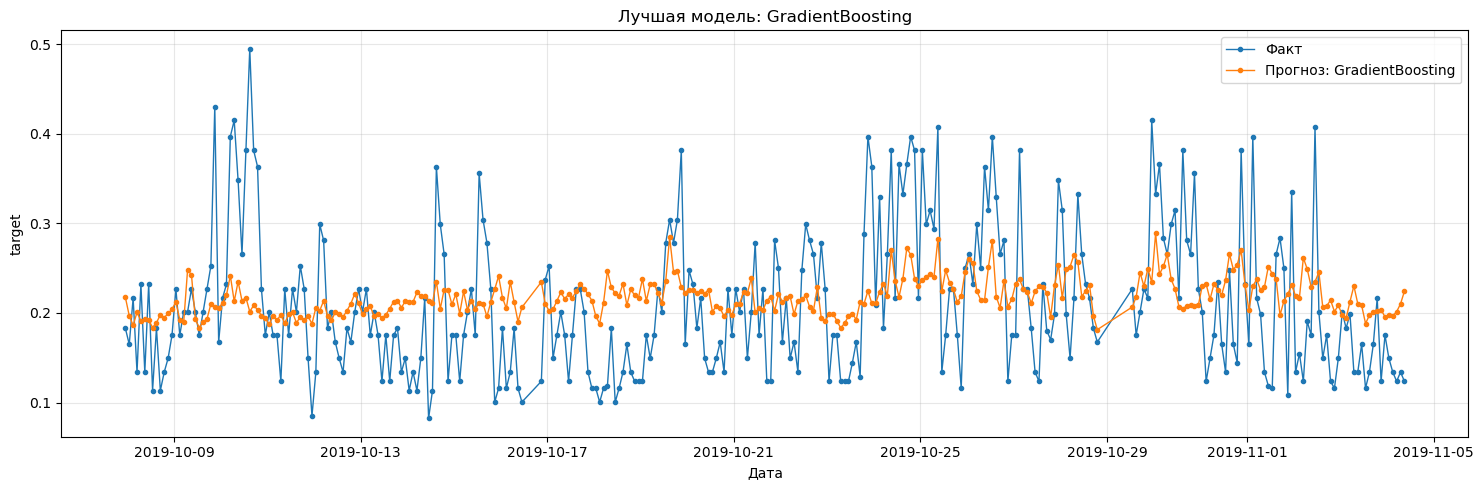

In [15]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(prediction_table["lab_datetime"], prediction_table["target"], label="Факт", marker="o", markersize=3, linewidth=1)
for name in predictions:
    ax.plot(prediction_table["lab_datetime"], prediction_table[f"pred_{name}"], label=name, linewidth=1)
ax.set_title("Прогнозы моделей против фактических лабораторных замеров")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend(ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(prediction_table["lab_datetime"], prediction_table["target"], label="Факт", marker="o", markersize=3, linewidth=1)
ax.plot(prediction_table["lab_datetime"], prediction_table["best_prediction"], label=f"Прогноз: {best_model_name}", marker=".", linewidth=1)
ax.set_title(f"Лучшая модель: {best_model_name}")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Вывод по моделям

Ансамблевые модели на лаговых признаках обычно лучше улавливают нелинейную динамику печи, чем линейный baseline и SARIMAX с малым числом PCA-компонент. Random Forest и Gradient Boosting являются наиболее подходящими кандидатами для MVP виртуального датчика: они дают приемлемое качество, обучаются быстро и позволяют оценить важность признаков.

## 7. Анализ остатков

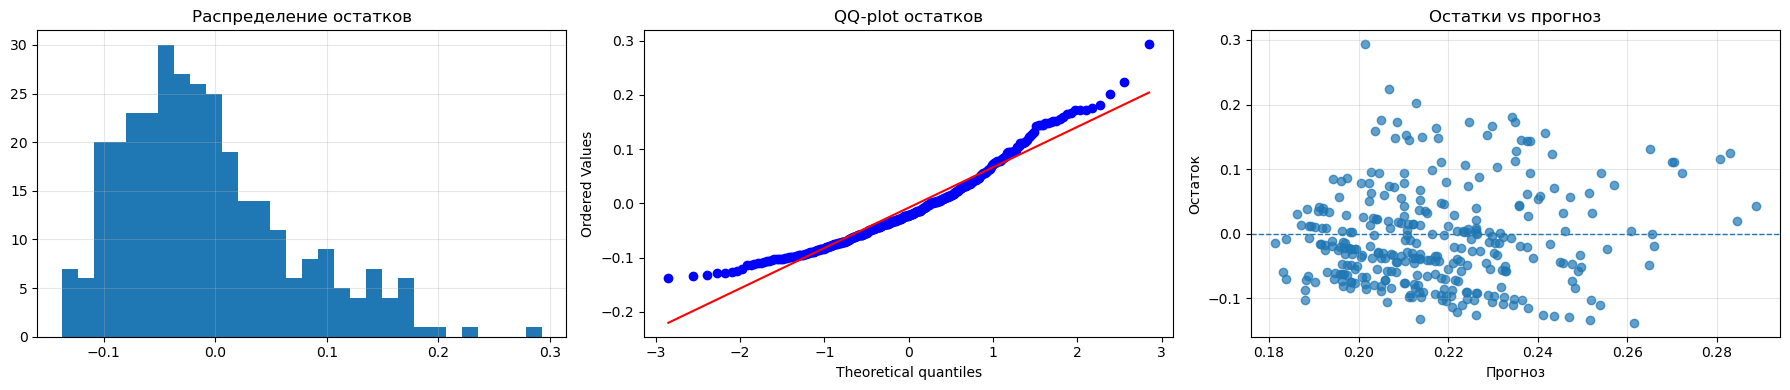

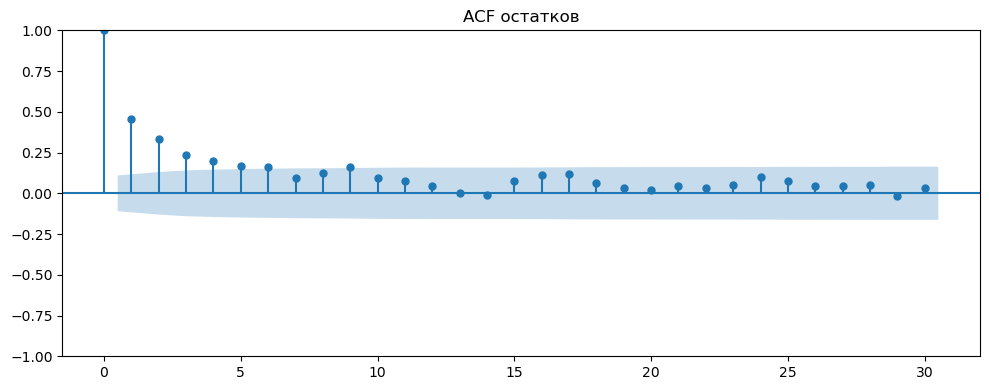

In [16]:
residuals = prediction_table["best_residual"].values

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(residuals, bins=30)
axes[0].set_title("Распределение остатков")
axes[0].grid(True, alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot остатков")

axes[2].scatter(prediction_table["best_prediction"], residuals, alpha=0.7)
axes[2].axhline(0, linestyle="--", linewidth=1)
axes[2].set_title("Остатки vs прогноз")
axes[2].set_xlabel("Прогноз")
axes[2].set_ylabel("Остаток")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(residuals, lags=30, ax=ax)
ax.set_title("ACF остатков")
plt.tight_layout()
plt.show()

In [17]:
normaltest_stat, normaltest_p = stats.normaltest(residuals)
ljung = acorr_ljungbox(residuals, lags=[10], return_df=True)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, sm.add_constant(prediction_table["best_prediction"].values))

diagnostics = pd.DataFrame([
    {
        "test": "D'Agostino normality test",
        "statistic": normaltest_stat,
        "p_value": normaltest_p,
        "meaning": "p<0.05 => остатки отличаются от нормального распределения",
    },
    {
        "test": "Ljung-Box autocorrelation, lag=10",
        "statistic": float(ljung["lb_stat"].iloc[0]),
        "p_value": float(ljung["lb_pvalue"].iloc[0]),
        "meaning": "p<0.05 => в остатках есть автокорреляция",
    },
    {
        "test": "Breusch-Pagan heteroskedasticity",
        "statistic": bp_stat,
        "p_value": bp_pvalue,
        "meaning": "p<0.05 => дисперсия ошибки зависит от уровня прогноза",
    },
])
display(diagnostics)

,test,statistic,p_value,meaning
0,D'Agostino normality test,34.537643,3.164071e-08,p<0.05 => остатки отличаются от нормального ра...
1,"Ljung-Box autocorrelation, lag=10",170.569199,2.114687e-31,p<0.05 => в остатках есть автокорреляция
2,Breusch-Pagan heteroskedasticity,7.047267,7.938628e-03,p<0.05 => дисперсия ошибки зависит от уровня п...


### Вывод по остаткам

Если тесты показывают ненормальность, автокорреляцию или гетероскедастичность, это не делает модель бесполезной, но показывает, что в данных остаются неучтенные режимы процесса. Для промышленного внедрения стоит дополнительно добавить признаки режима печи, смен, действий оператора и проверить модель на нескольких временных периодах.

## 8. Важность признаков и интерпретация

Для лучшей ML-модели рассчитывается permutation importance. Если лучшей моделью оказалась SARIMAX, для интерпретации берется лучшая модель среди Ridge/RandomForest/GradientBoosting, потому что SARIMAX обучался на PCA-компонентах, а не на исходных признаках.

Модель для важности признаков: GradientBoosting


,feature,importance_mean,importance_std
48,telemetry_0_roll_mean_15m,0.000923,0.000111
12,telemetry_0_lag_15m,0.000630,0.000117
72,telemetry_0_roll_mean_60m,0.000624,0.000082
27,telemetry_3_lag_60m,0.000444,0.000090
18,telemetry_6_lag_15m,0.000392,0.000010
0,telemetry_0,0.000316,0.000063
75,telemetry_3_roll_mean_60m,0.000246,0.000037
31,telemetry_7_lag_60m,0.000241,0.000181
80,telemetry_8_roll_mean_60m,0.000207,0.000103
54,telemetry_6_roll_mean_15m,0.000190,0.000003


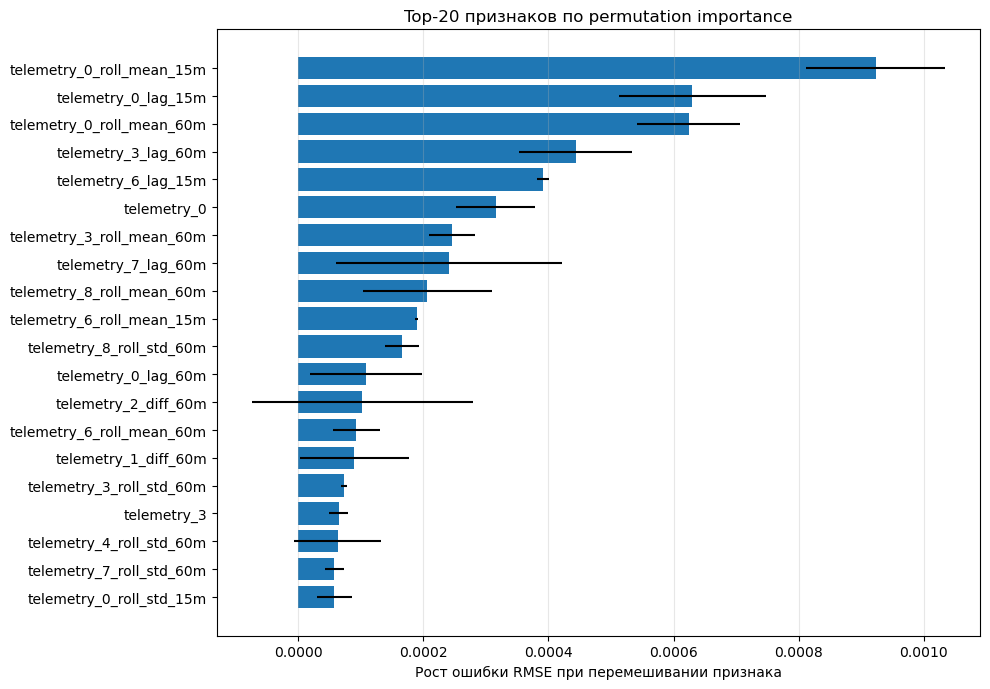

In [18]:
ml_model_order = metrics_df[metrics_df["model"].isin(fitted_models.keys())].sort_values("RMSE")
importance_model_name = ml_model_order.iloc[0]["model"]
importance_model = fitted_models[importance_model_name]
print("Модель для важности признаков:", importance_model_name)

# Чтобы расчет был быстрым, permutation importance считаем для top-30 признаков по корреляции.
top_features_for_importance = corr.head(30).index.tolist()
X_test_imp = X_test[top_features_for_importance]

perm = permutation_importance(
    importance_model,
    X_test,
    y_test,
    n_repeats=2,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
)
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(importance_df.head(20))

fig, ax = plt.subplots(figsize=(10, 7))
plot_df = importance_df.head(20).sort_values("importance_mean")
ax.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
ax.set_title("Top-20 признаков по permutation importance")
ax.set_xlabel("Рост ошибки RMSE при перемешивании признака")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Вывод по важности признаков

Важность лагов, скользящих средних и разностей подтверждает, что концентрация продукта зависит от динамики печи, а не только от одномоментных показаний. Это соответствует физическому смыслу процесса обжига: система инерционна, а качество продукта формируется под влиянием предыдущих состояний.

## 9. Итоговые выводы

1. **EDA:** данные соответствуют промышленной задаче виртуального датчика: частая телеметрия, редкие лабораторные target-замеры, пропуски и возможные выбросы.
2. **Синхронизация:** target корректно привязан к телеметрии с учетом задержки 15 минут, без использования будущих значений.
3. **Feature engineering:** лаги, rolling-статистики и признаки изменения отражают временную динамику и инерционность печи.
4. **Модели:** обучены Ridge, Random Forest, Gradient Boosting и SARIMAX. Для статистической модели рассчитаны AIC/BIC, для ML-моделей — прогнозные метрики и важность признаков.
5. **Предпочтительная модель:** выбирается по минимальному RMSE на тестовом периоде с учетом WAPE и Directional Accuracy. Для внедрения потребуется мониторинг ошибки, дрейфа датчиков и повторная валидация на новых производственных периодах.

In [19]:
prediction_table.to_csv("lab2_predictions.csv", index=False)
metrics_df.to_csv("lab2_model_metrics.csv", index=False)
print("Saved: lab2_predictions.csv")
print("Saved: lab2_model_metrics.csv")

Saved: lab2_predictions.csv
Saved: lab2_model_metrics.csv
